# Exploratory Data Analysis (EDA)

## Objective
The objective of this notebook is to explore the transaction dataset to understand its structure, identify data quality issues, detect patterns, and generate insights that will guide feature engineering and credit risk modeling.

This step is crucial for understanding customer behavior before building a proxy-based credit scoring model.

# 1. Dataset Overview and Loading

- The dataset contains transaction-level records.
- Each row represents a single customer transaction.
- Columns include numerical, categorical, and temporal features.
- The dataset does not contain a direct default label, which confirms the need for proxy-based labeling later.

In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import (
    load_data,
    validate_dataset,
    summarize_data,
    missing_values,
    get_numerical_columns,
    get_categorical_columns
)

DATA_PATH = "../data/raw/data.csv"

df = load_data(DATA_PATH)

validate_dataset(df)
df.head()

Dataset loaded successfully.
Dataset validation passed.


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
df.shape

(95662, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

# 2. Summary Statistics

The summary statistics provide insights into:
- Central tendency (mean, median)
- Spread of data (standard deviation, min, max)
- Potential skewness in numerical features

This helps identify unusual distributions and potential outliers early in the analysis.

In [17]:
summarize_data(df)

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


# 3, Numerical Feature Distributions

The distributions of numerical features help identify:
- Skewed variables (common in financial data)
- Presence of extreme values
- Customer spending behavior patterns

Most financial transaction data is expected to be right-skewed, where a small number of customers contribute to large transaction amounts.

In [18]:
def plot_numerical_distributions(df):

    numerical_cols = get_numerical_columns(df)

    for col in numerical_cols:

        plt.figure(figsize=(8,4))

        sns.histplot(
            data=df,
            x=col,
            kde=True
        )

        plt.title(
            f"Distribution of {col}"
        )

        plt.show()

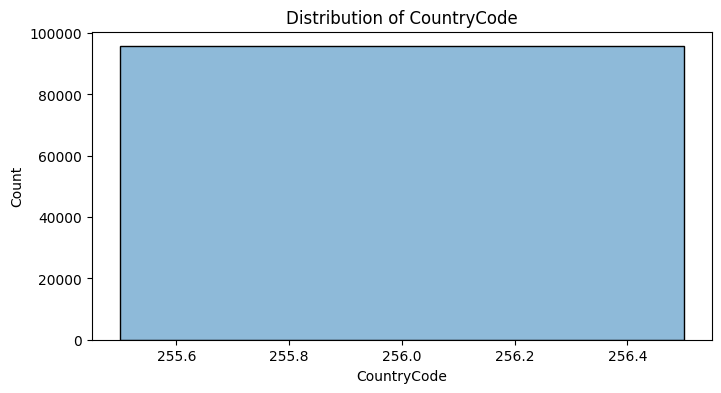

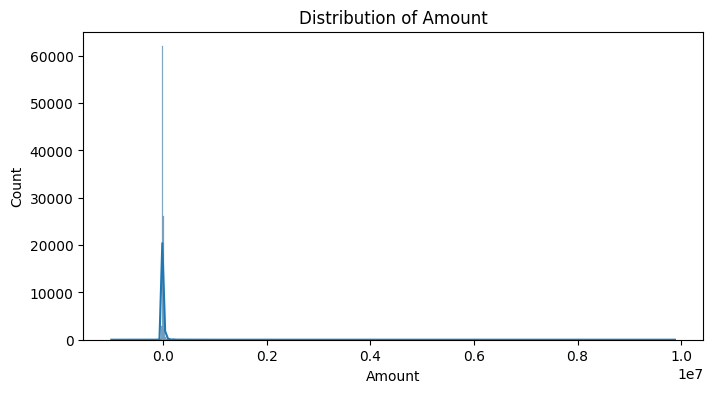

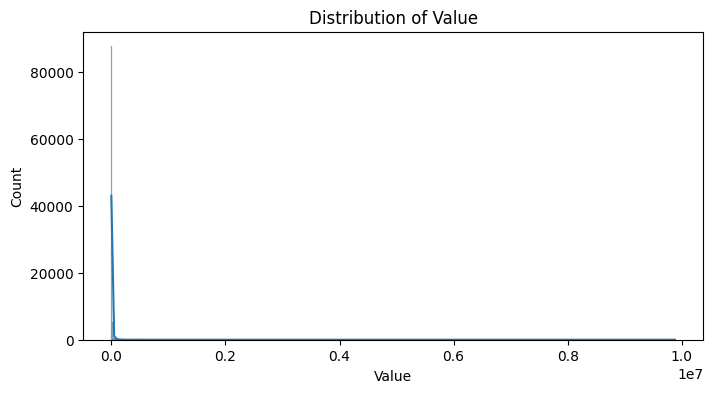

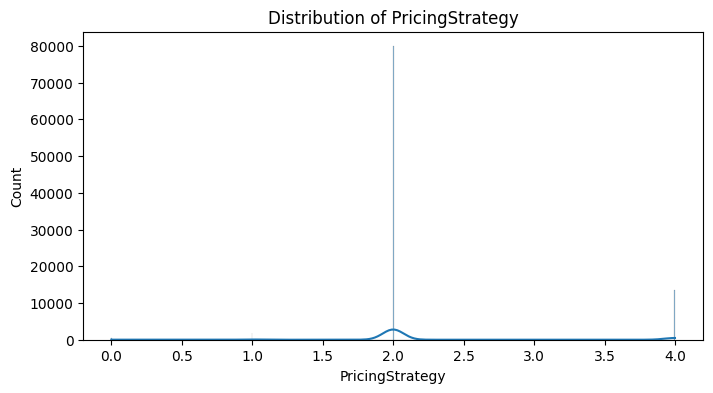

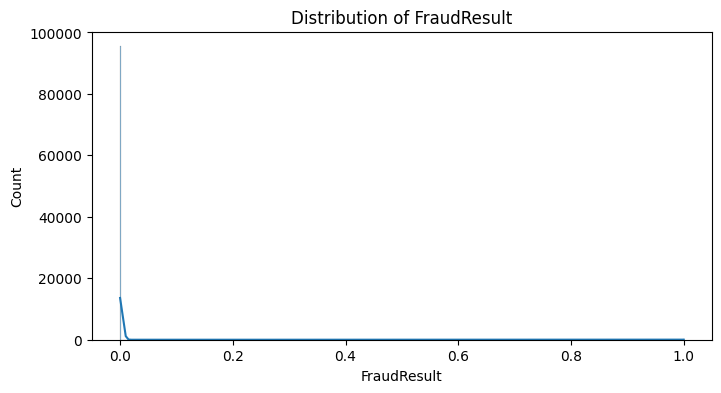

In [19]:
plot_numerical_distributions(df)

# 4. Categorical Feature Analysis

Categorical features show:
- Most frequent transaction types
- Dominant customer behavior patterns
- Rare categories that may require grouping

This helps understand how customers interact with the platform.

In [20]:
def plot_categorical_features(df):

    categorical_cols = get_categorical_columns(df)

    for col in categorical_cols:

        plt.figure(figsize=(8,4))

        (
            df[col]
            .value_counts()
            .head(10)
            .plot(kind="bar")
        )

        plt.title(
            f"Top Categories in {col}"
        )

        plt.show()

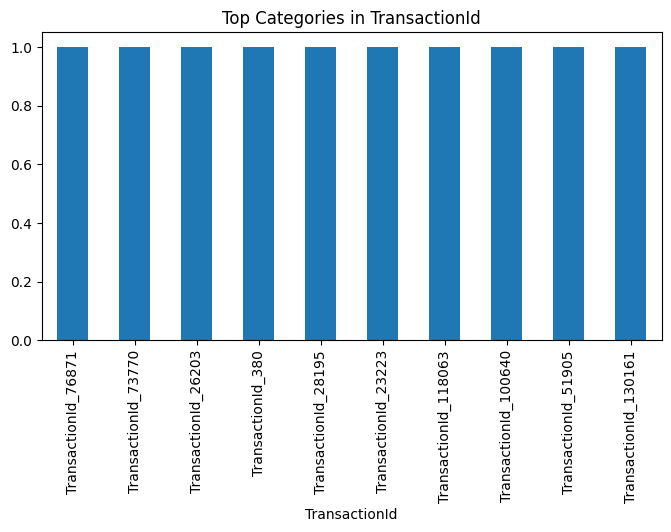

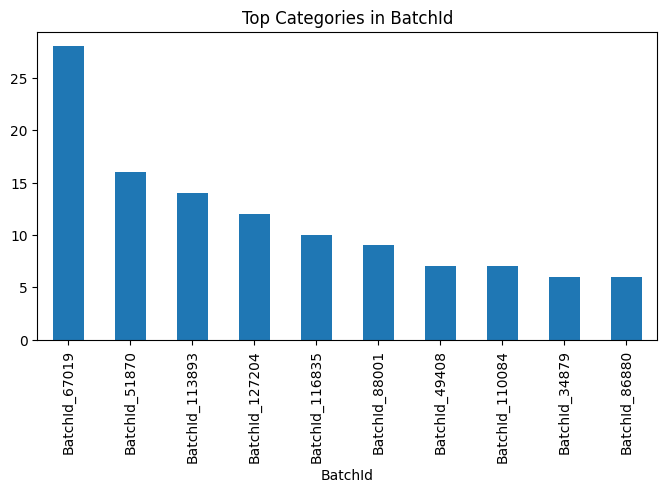

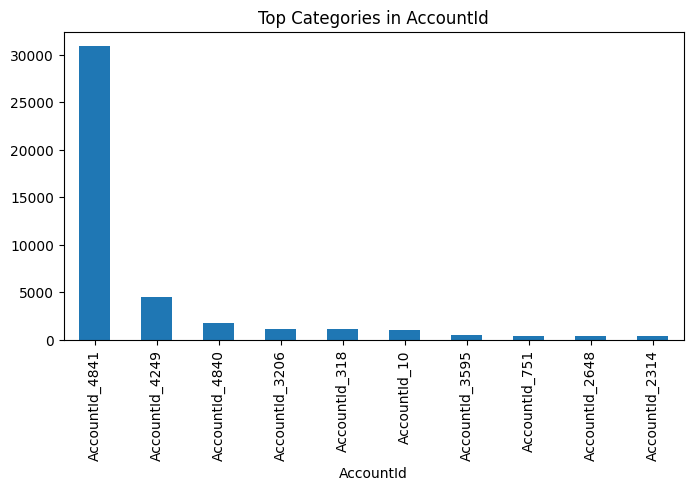

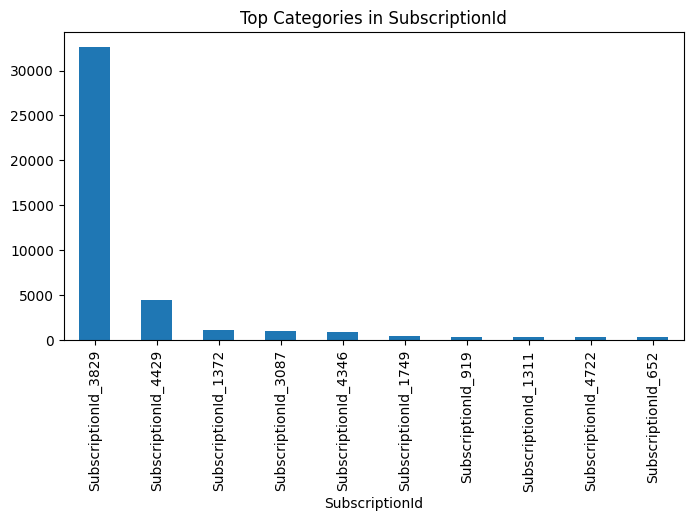

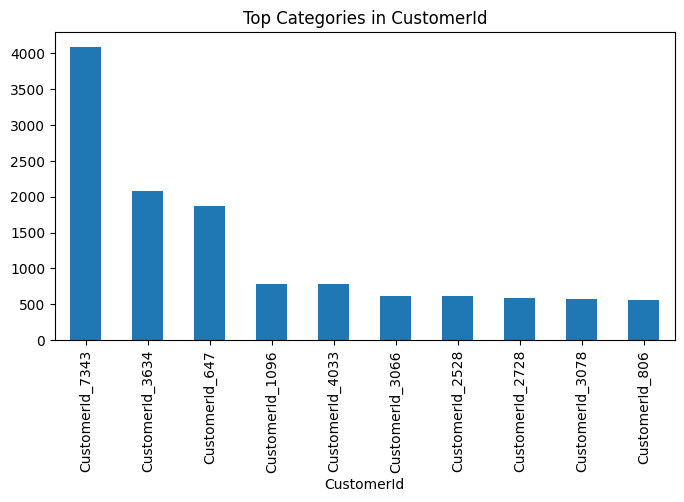

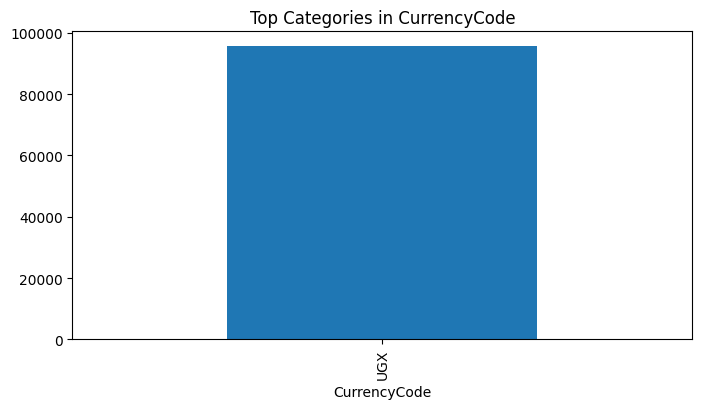

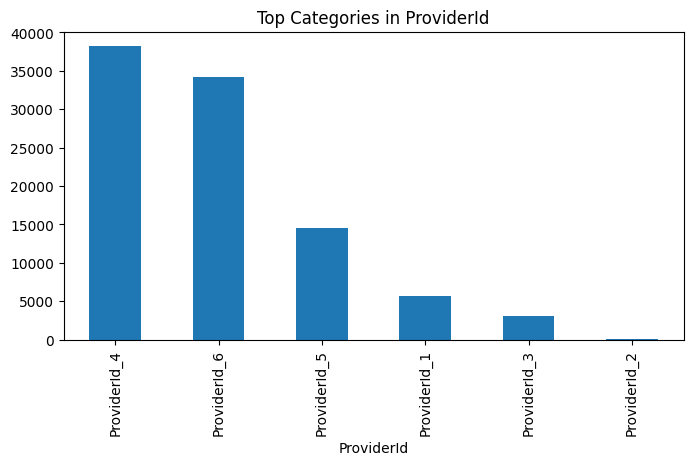

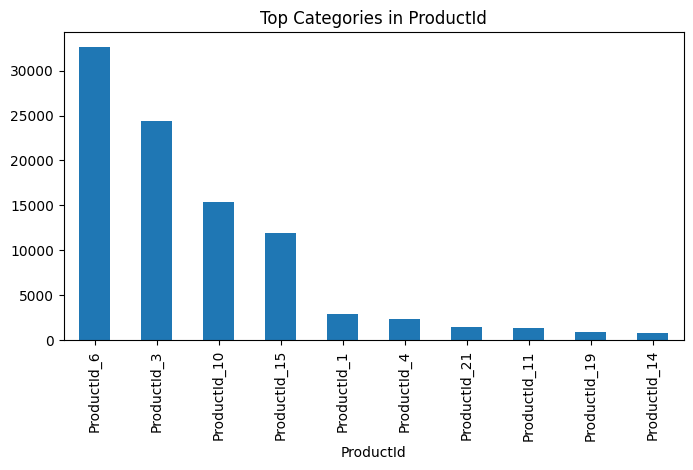

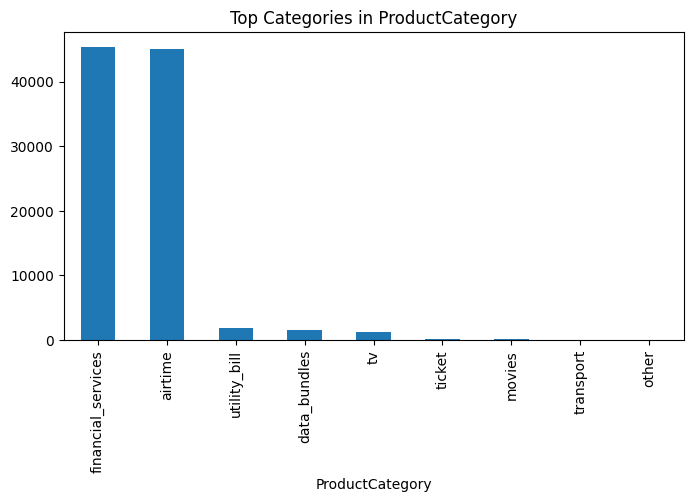

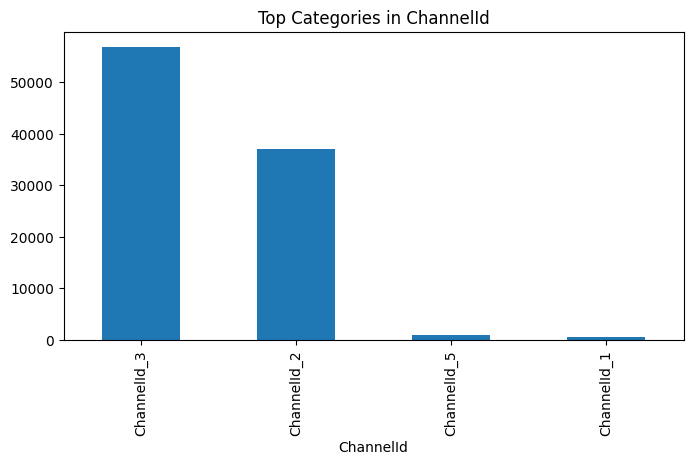

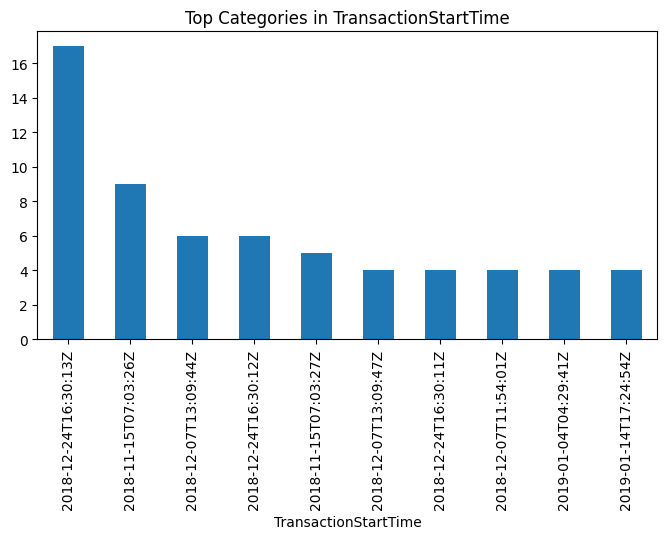

In [21]:
plot_categorical_features(df)

# 5. Correlation Analysis

Correlation analysis helps identify relationships between numerical features.

- Strong correlations may indicate redundant features
- Weak correlations may indicate independent signals
- These insights are important for feature selection during modeling

In [22]:
def plot_correlation_matrix(df):

    numerical_df = df.select_dtypes(
        include=np.number
    )

    plt.figure(
        figsize=(10,6)
    )

    sns.heatmap(
        numerical_df.corr(),
        cmap="coolwarm"
    )

    plt.title(
        "Correlation Matrix"
    )

    plt.show()

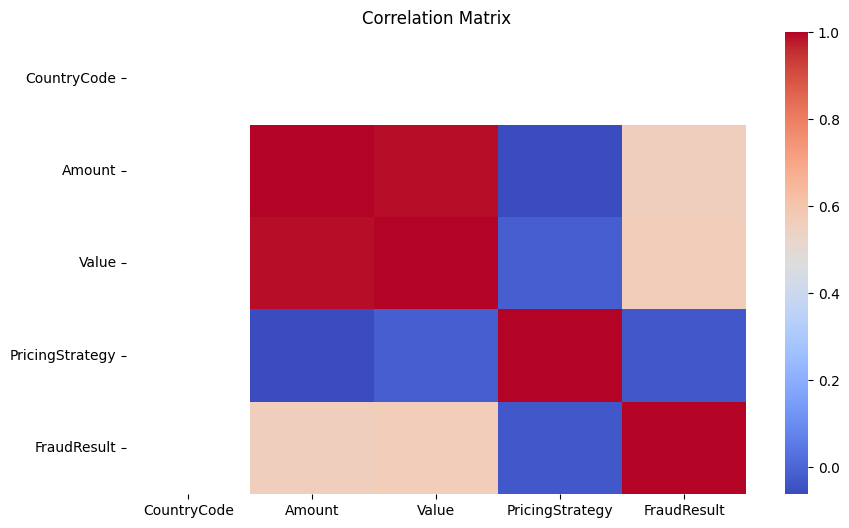

In [23]:
plot_correlation_matrix(df)

# 6. Missing Values Analysis

This section identifies missing data in the dataset.

Handling missing values is important because:
- Machine learning models cannot handle null values directly
- Improper handling may introduce bias
- Different strategies (mean, median, mode) may be required depending on feature type

In [24]:
missing_values(df)

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

# 7. Outlier Detection

Boxplots are used to detect extreme values in numerical features.

Outliers may represent:
- High-value customers
- Fraudulent transactions
- Data entry errors

These will need careful handling during preprocessing and modeling.

In [25]:
def detect_outliers(df):

    numerical_cols = get_numerical_columns(df)

    for col in numerical_cols:

        plt.figure(
            figsize=(8,4)
        )

        sns.boxplot(
            x=df[col]
        )

        plt.title(
            f"Outliers in {col}"
        )

        plt.show()

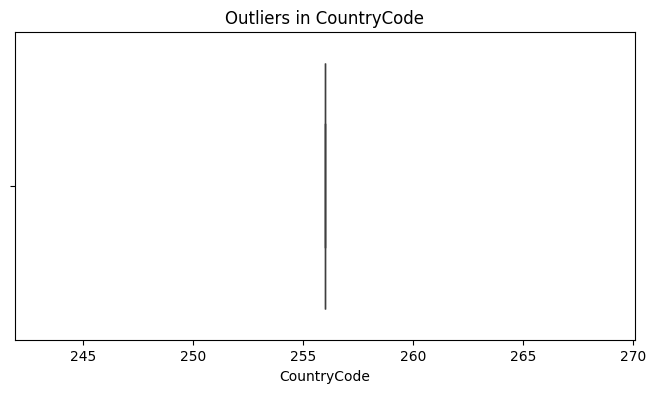

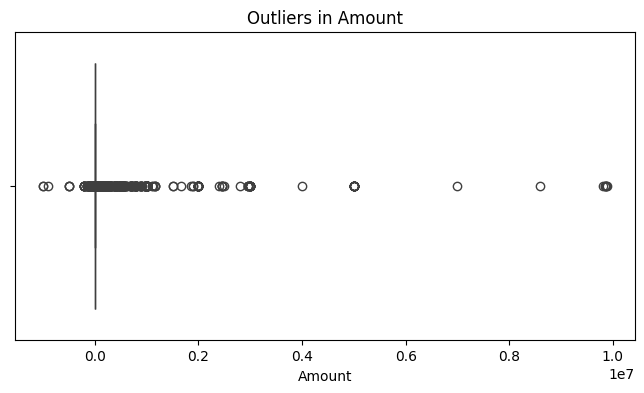

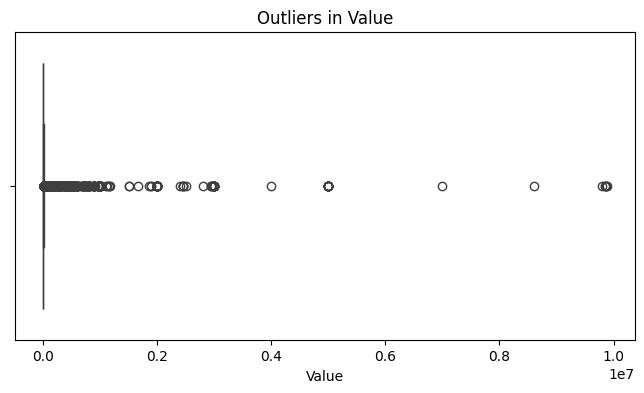

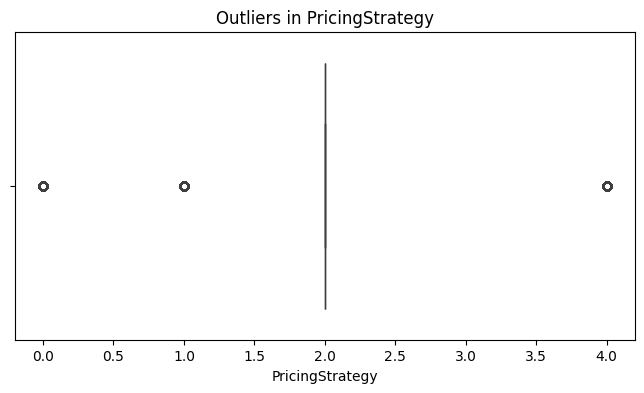

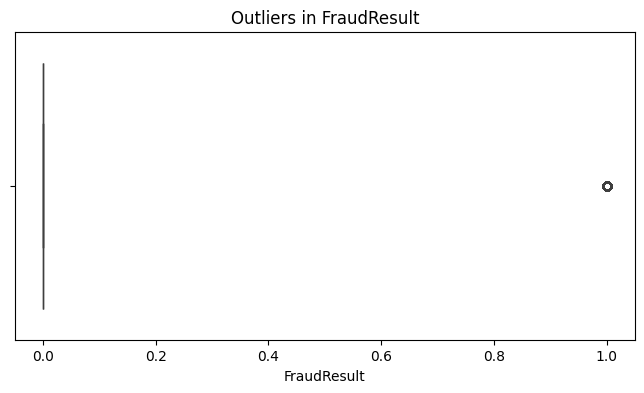

In [26]:
detect_outliers(df)

## Hypotheses for Feature Engineering

Based on the exploratory analysis, the following hypotheses will guide feature engineering:

- Customers with frequent and high-value transactions may exhibit lower credit risk.
- Transaction channel preferences may provide behavioral signals related to customer reliability.
- Product and provider usage patterns may help differentiate customer segments.
- Recency, frequency, and monetary behavior are likely to be useful indicators for constructing a proxy credit risk target.
- Extreme transaction behaviors may contain valuable information for distinguishing customer risk profiles.

# Key Insights from EDA

1. The dataset demonstrates good overall quality, with complete records and no significant data completeness issues.

2. Transaction-related features exhibit strong positive skewness, indicating that customer activity is concentrated among a relatively small group of high-value transactions.

3. Several numerical variables contain notable outliers that may represent high-value customers, unusual transaction behavior, or potentially fraudulent activity.

4. Fraudulent transactions are relatively rare, suggesting that future predictive modeling tasks may need to address class imbalance.

5. Customer activity appears concentrated within a limited number of transaction categories and service providers, indicating potentially useful behavioral signals for credit risk assessment.